In [1]:
import loompy as lp
import pandas as pd

In [2]:
pdir = "/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/"
MODULE_PATH = pdir+"processed-data/09_SCENIC/AUCell_modules/"

In [3]:
def extract_aucell(group, cluster):
    lf = lp.connect(MODULE_PATH+"spe-n119_"+group+cluster+"_13844-genes_no-lowUMI_logcounts_modules-AUCell-fixed-thold.loom", mode='r+', validate=False)
    auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
    cell_mtx = pd.DataFrame({"seurat_label": lf.ca.seurat_label, "smoothed_k9_1663": lf.ca.smoothed_k9_1663, "custom_cluster": cluster,
                             "sex": lf.ca.sex, "condition": lf.ca.condition, "nGene": lf.ca.nGene, "nUMI": lf.ca.nUMI}, index=lf.ca.CellID)
    lf.close()
    
    signature_column_names = list(auc_mtx.select_dtypes('number').columns)
    signature_column_names = list(map(lambda s: s[12:], signature_column_names))
    auc_mtx.columns = signature_column_names
    
    return auc_mtx, cell_mtx

In [4]:
auc_mv, cell_mv = extract_aucell("seurat-label-", "Micro.Vasc")
auc_agl, cell_agl = extract_aucell("custom-cluster-", "Astro.Glia")
auc_anr, cell_anr = extract_aucell("custom-cluster-", "Astro.Nrn")
auc_l2, cell_l2 = extract_aucell("custom-cluster-", "L2")
auc_l3, cell_l3 = extract_aucell("custom-cluster-", "L3")
auc_l4, cell_l4 = extract_aucell("seurat-label-", "L4")
auc_inh, cell_inh = extract_aucell("seurat-label-", "Inhb")
auc_l5, cell_l5 = extract_aucell("seurat-label-", "L5")
auc_l6, cell_l6 = extract_aucell("seurat-label-", "L6")
auc_wm, cell_wm = extract_aucell("seurat-label-", "Oligo")

In [33]:
#auc_ast, cell_ast = extract_aucell("seurat-label-Astro")
#auc_l23, cell_l23 = extract_aucell("seurat-label-L2.3")

In [5]:
auc_all = pd.concat([auc_mv, auc_agl, auc_anr, auc_l2, auc_l3, auc_l4, auc_inh, auc_l5, auc_l6, auc_wm])

In [6]:
cell_all = pd.concat([cell_mv, cell_agl, cell_anr, cell_l2, cell_l3, cell_l4, cell_inh, cell_l5, cell_l6, cell_wm])

In [7]:
joined_all = pd.concat([auc_all, cell_all], axis=1)
joined_all.shape

(513200, 166)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
transfer_bright = {'Micro.Vasc': "#911223", 'Astro': "#cfa45c", 'L2.3': "#088F8F", 'L4': "#c2cfcf",
                   'Inhb': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'Oligo': "#D1C4B0"}
smoothed_bright = {'Vasc': "#911223", 'L1': "#cfa45c", 'L2': "#5D9940", 'L3.4': "#5095CD",
                  'GABA': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'WM': "#D1C4B0"}
custom_colors = {'Micro.Vasc': "#911223", 'Astro.Glia': "#cfa45c", 'Astro.Nrn': "#F5D29E", 
                 'L2': "#5D9940", 'L3': "#5095CD",'L4': "#c2cfcf",'Inhb': "#9377AC", 
                 'L5': "#ddc94e", 'L6': "#E45C5F", 'Oligo': "#D1C4B0"}

## cell count and detected genes plots

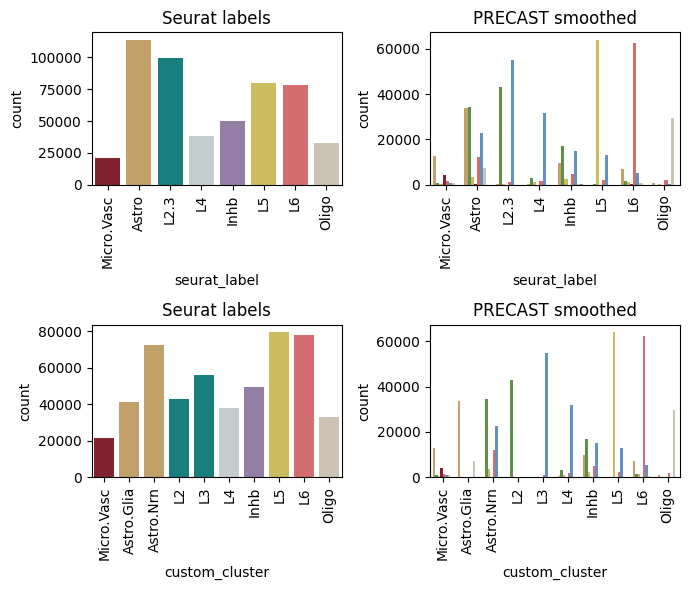

In [10]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(7, 6))

sns.countplot(cell_all, x="seurat_label", hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title('Seurat labels')
ax1.tick_params(axis='x', rotation=90)

sns.countplot(cell_all, x="seurat_label", hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title('PRECAST smoothed')
ax2.tick_params(axis='x', rotation=90)

sns.countplot(cell_all, x="custom_cluster", hue="seurat_label", palette=transfer_bright, legend=False, ax=ax3)
ax3.set_title('Seurat labels')
ax3.tick_params(axis='x', rotation=90)

sns.countplot(cell_all, x="custom_cluster", hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax4)
ax4.set_title('PRECAST smoothed')
ax4.tick_params(axis='x', rotation=90)

plt.tight_layout()

In [ ]:
#micro.vasc = itself
#check out astro L1 vs L2 vs L3.4 vs L5
#check out l2.3 L2 vs L3.4
#L4 = itself
#inhb = itself?
#L5 = itself
#l6 = itself
#oligo = itself

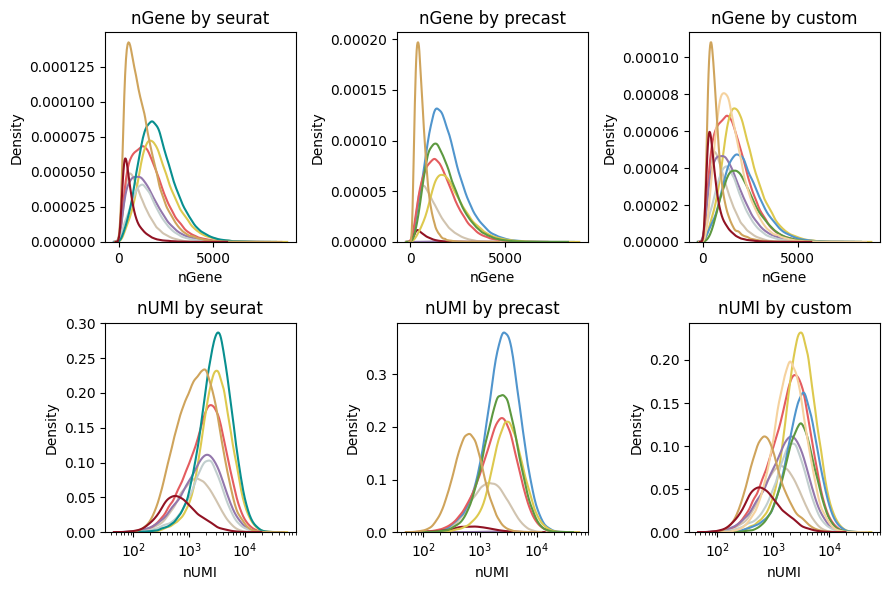

In [11]:
gene1 = "nGene"
gene2 = "nUMI"

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(9, 6))
sns.kdeplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.kdeplot(data=joined_all, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")
sns.kdeplot(data=joined_all, x=gene1, hue="custom_cluster", palette=custom_colors, legend=False, ax=ax3)
ax3.set_title(gene1+" by custom")

sns.kdeplot(data=joined_all, x=gene2, hue="seurat_label", palette=transfer_bright, legend=False, log_scale=True, ax=ax4)
ax4.set_title(gene2+" by seurat")
sns.kdeplot(data=joined_all, x=gene2, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, log_scale=True, ax=ax5)
ax5.set_title(gene2+" by precast")
sns.kdeplot(data=joined_all, x=gene2, hue="custom_cluster", palette=custom_colors, legend=False, log_scale=True, ax=ax6)
ax6.set_title(gene2+" by custom")

plt.tight_layout()

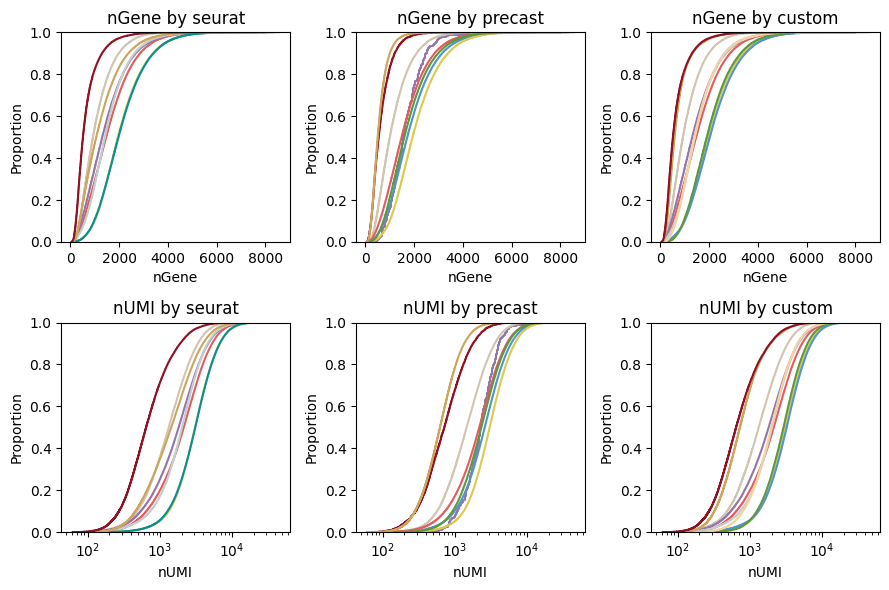

In [12]:
gene1 = "nGene"
gene2 = "nUMI"

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(9, 6))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_all, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")
sns.ecdfplot(data=joined_all, x=gene1, hue="custom_cluster", palette=custom_colors, legend=False, ax=ax3)
ax3.set_title(gene1+" by custom")

sns.ecdfplot(data=joined_all, x=gene2, hue="seurat_label", palette=transfer_bright, legend=False, log_scale=True, ax=ax4)
ax4.set_title(gene2+" by seurat")
sns.ecdfplot(data=joined_all, x=gene2, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, log_scale=True, ax=ax5)
ax5.set_title(gene2+" by precast")
sns.ecdfplot(data=joined_all, x=gene2, hue="custom_cluster", palette=custom_colors, legend=False, log_scale=True, ax=ax6)
ax6.set_title(gene2+" by custom")

plt.tight_layout()

## AUCell module output plots

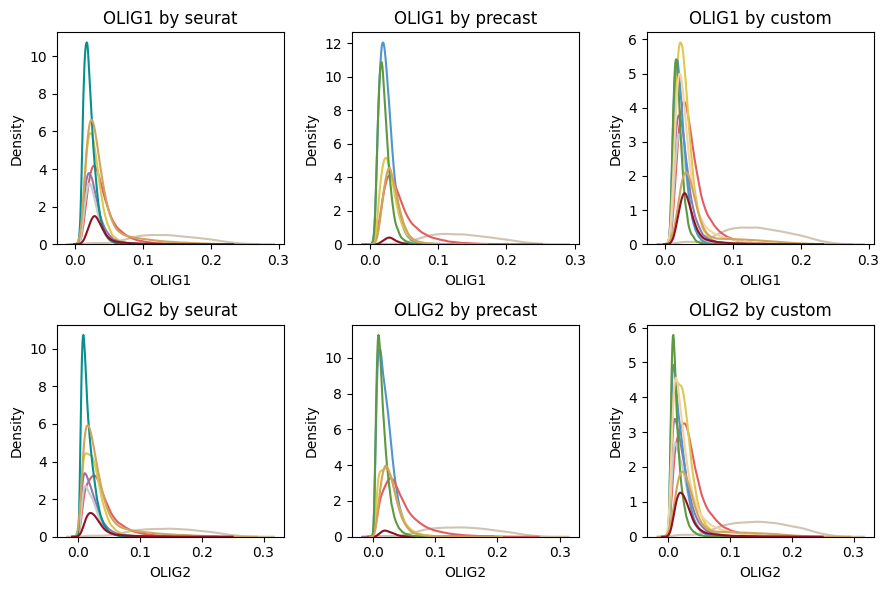

In [13]:
gene1 = "OLIG1" #726 module genes
gene2 = "OLIG2" #273 module genes

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(9, 6))
sns.kdeplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.kdeplot(data=joined_all, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")
sns.kdeplot(data=joined_all, x=gene1, hue="custom_cluster", palette=custom_colors, legend=False, ax=ax3)
ax3.set_title(gene1+" by custom")

sns.kdeplot(data=joined_all, x=gene2, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax4)
ax4.set_title(gene2+" by seurat")
sns.kdeplot(data=joined_all, x=gene2, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax5)
ax5.set_title(gene2+" by precast")
sns.kdeplot(data=joined_all, x=gene2, hue="custom_cluster", palette=custom_colors, legend=False, ax=ax6)
ax6.set_title(gene2+" by custom")

plt.tight_layout()

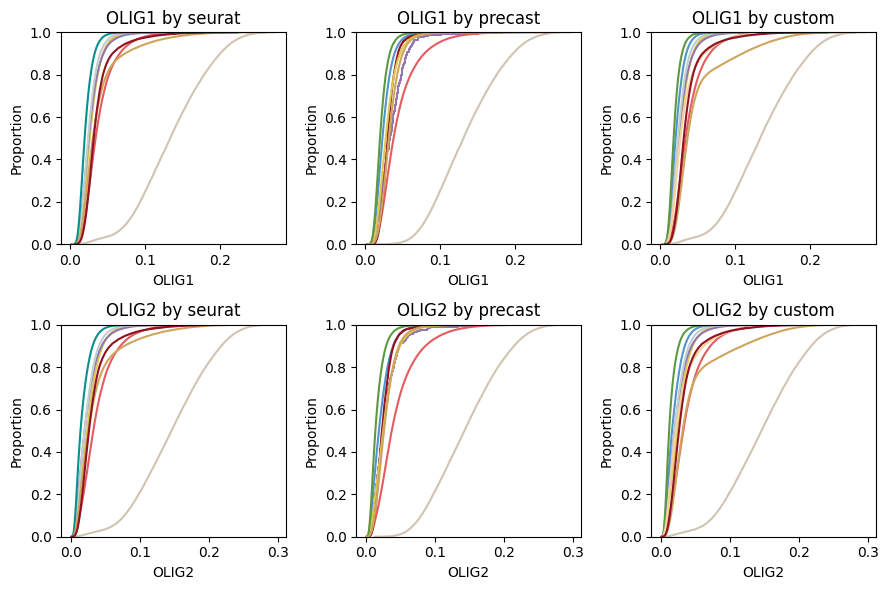

In [14]:
gene1 = "OLIG1" #726 module genes
gene2 = "OLIG2" #273 module genes

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(9, 6))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_all, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")
sns.ecdfplot(data=joined_all, x=gene1, hue="custom_cluster", palette=custom_colors, legend=False, ax=ax3)
ax3.set_title(gene1+" by custom")

sns.ecdfplot(data=joined_all, x=gene2, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax4)
ax4.set_title(gene2+" by seurat")
sns.ecdfplot(data=joined_all, x=gene2, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax5)
ax5.set_title(gene2+" by precast")
sns.ecdfplot(data=joined_all, x=gene2, hue="custom_cluster", palette=custom_colors, legend=False, ax=ax6)
ax6.set_title(gene2+" by custom")

plt.tight_layout()

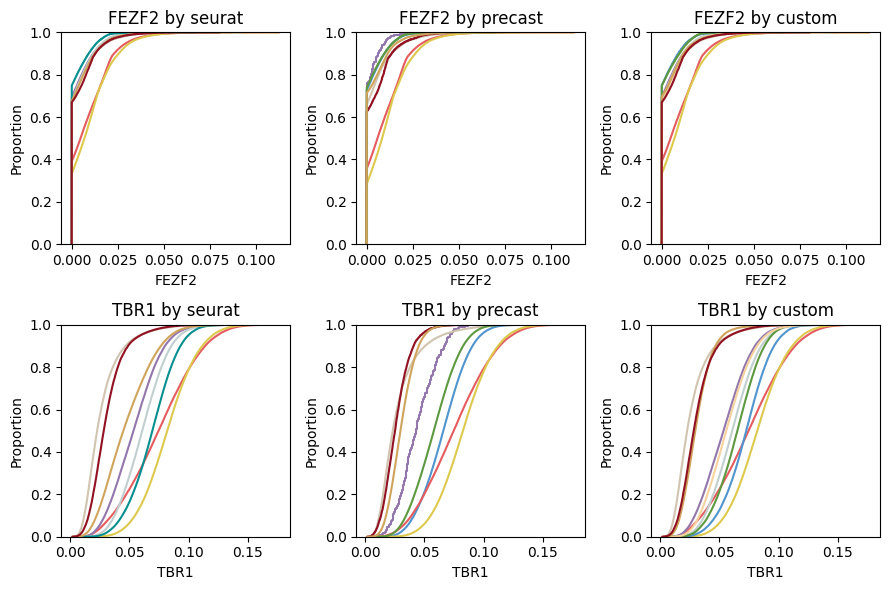

In [15]:
gene1 = "FEZF2" #49 module genes
gene2 = "TBR1" #389 module genes

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(9, 6))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_all, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")
sns.ecdfplot(data=joined_all, x=gene1, hue="custom_cluster", palette=custom_colors, legend=False, ax=ax3)
ax3.set_title(gene1+" by custom")

sns.ecdfplot(data=joined_all, x=gene2, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax4)
ax4.set_title(gene2+" by seurat")
sns.ecdfplot(data=joined_all, x=gene2, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax5)
ax5.set_title(gene2+" by precast")
sns.ecdfplot(data=joined_all, x=gene2, hue="custom_cluster", palette=custom_colors, legend=False, ax=ax6)
ax6.set_title(gene2+" by custom")

plt.tight_layout()

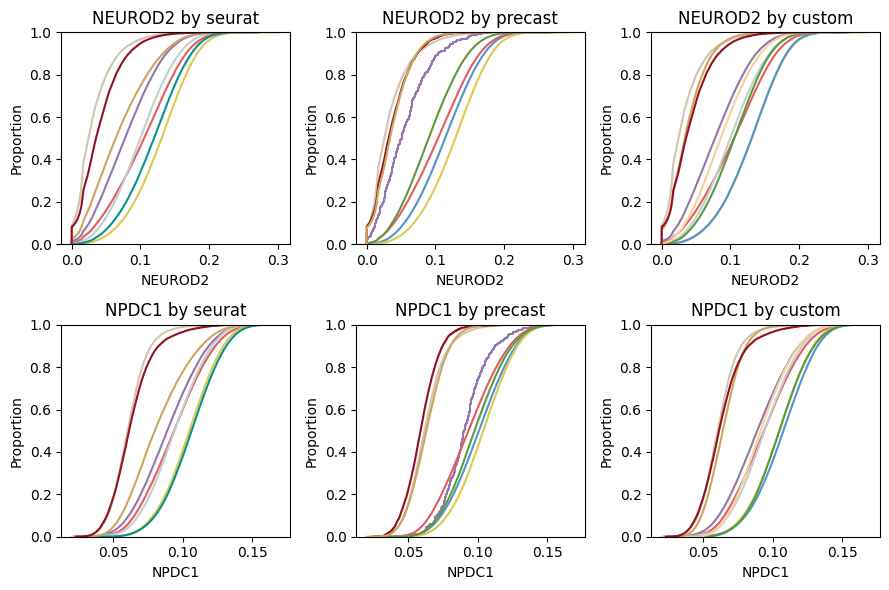

In [63]:
gene1 = "NEUROD2" #35 module genes
gene2 = "NPDC1" #2779 module genes

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(9, 6))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_all, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")
sns.ecdfplot(data=joined_all, x=gene1, hue="custom_cluster", palette=custom_colors, legend=False, ax=ax3)
ax3.set_title(gene1+" by custom")

sns.ecdfplot(data=joined_all, x=gene2, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax4)
ax4.set_title(gene2+" by seurat")
sns.ecdfplot(data=joined_all, x=gene2, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax5)
ax5.set_title(gene2+" by precast")
sns.ecdfplot(data=joined_all, x=gene2, hue="custom_cluster", palette=custom_colors, legend=False, ax=ax6)
ax6.set_title(gene2+" by custom")

plt.tight_layout()

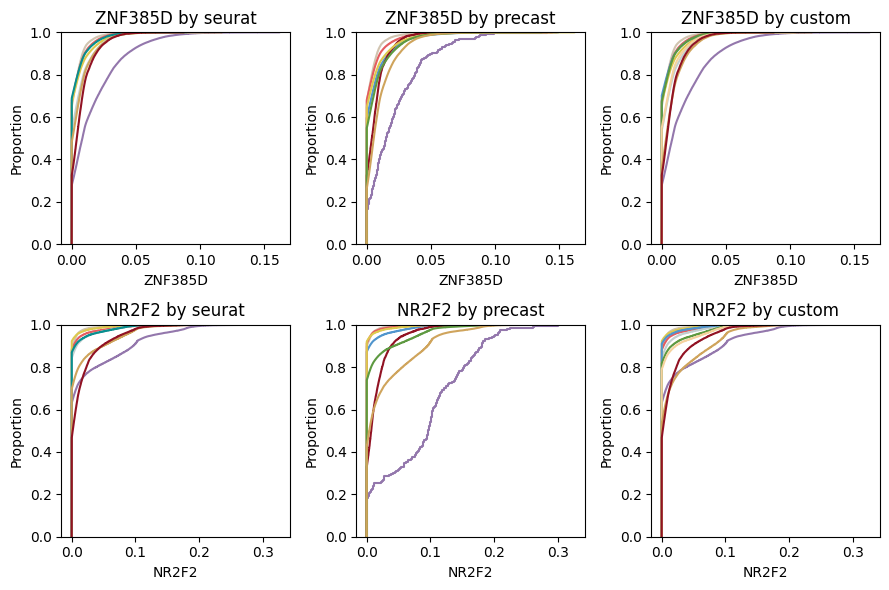

In [16]:
gene1 = "ZNF385D" #60 module genes
gene2 = "NR2F2" #36 module genes

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(9, 6))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_all, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")
sns.ecdfplot(data=joined_all, x=gene1, hue="custom_cluster", palette=custom_colors, legend=False, ax=ax3)
ax3.set_title(gene1+" by custom")

sns.ecdfplot(data=joined_all, x=gene2, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax4)
ax4.set_title(gene2+" by seurat")
sns.ecdfplot(data=joined_all, x=gene2, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax5)
ax5.set_title(gene2+" by precast")
sns.ecdfplot(data=joined_all, x=gene2, hue="custom_cluster", palette=custom_colors, legend=False, ax=ax6)
ax6.set_title(gene2+" by custom")

plt.tight_layout()

In [17]:
sns.set_theme(font_scale=.7)

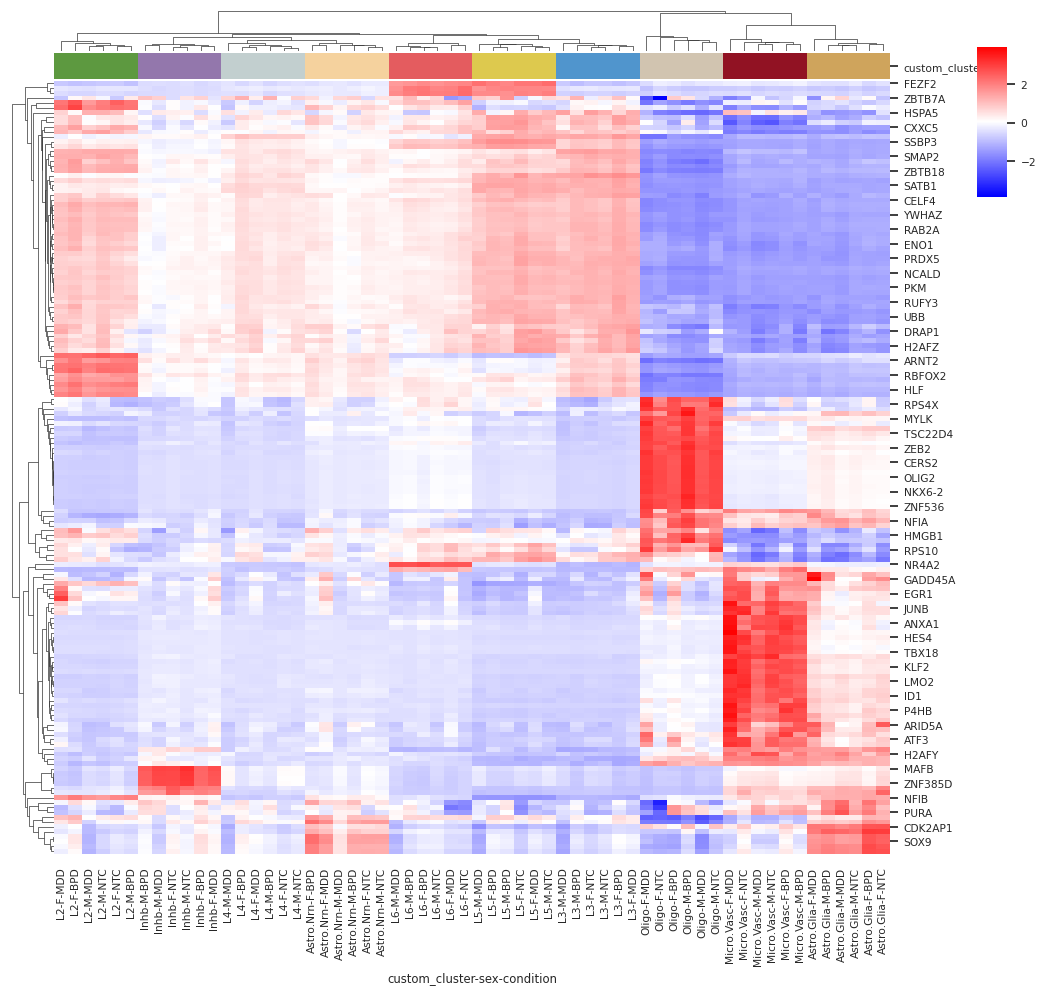

In [31]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['custom_cluster','sex','condition']]
df_means = df_scores.groupby(by=['custom_cluster','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['custom_cluster'] = [x[0] for x in df_means.index]
row_colors = colors_df['custom_cluster'].map(custom_colors)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

In [19]:
laDEGs = pd.read_csv(pdir+"processed-data/07_dx_DE/layer-adjusted-pc3-age-nspots_smoothed-k9-1663_dx-sex_degs-F-test-t-test.csv")
lrDEGs = pd.read_csv(pdir+"processed-data/07_dx_DE/layer-restricted-pc3-age-nspots_smoothed-k9-1663_dx-sex_degs-F-test-t-test.csv")
mbvDEGs = list(set(pd.concat([laDEGs.gene_name, lrDEGs.gene_name])))
len(mbvDEGs)

649

In [20]:
tfDEGs = list(set(df_means.columns).intersection(set(mbvDEGs)))
len(tfDEGs)

27

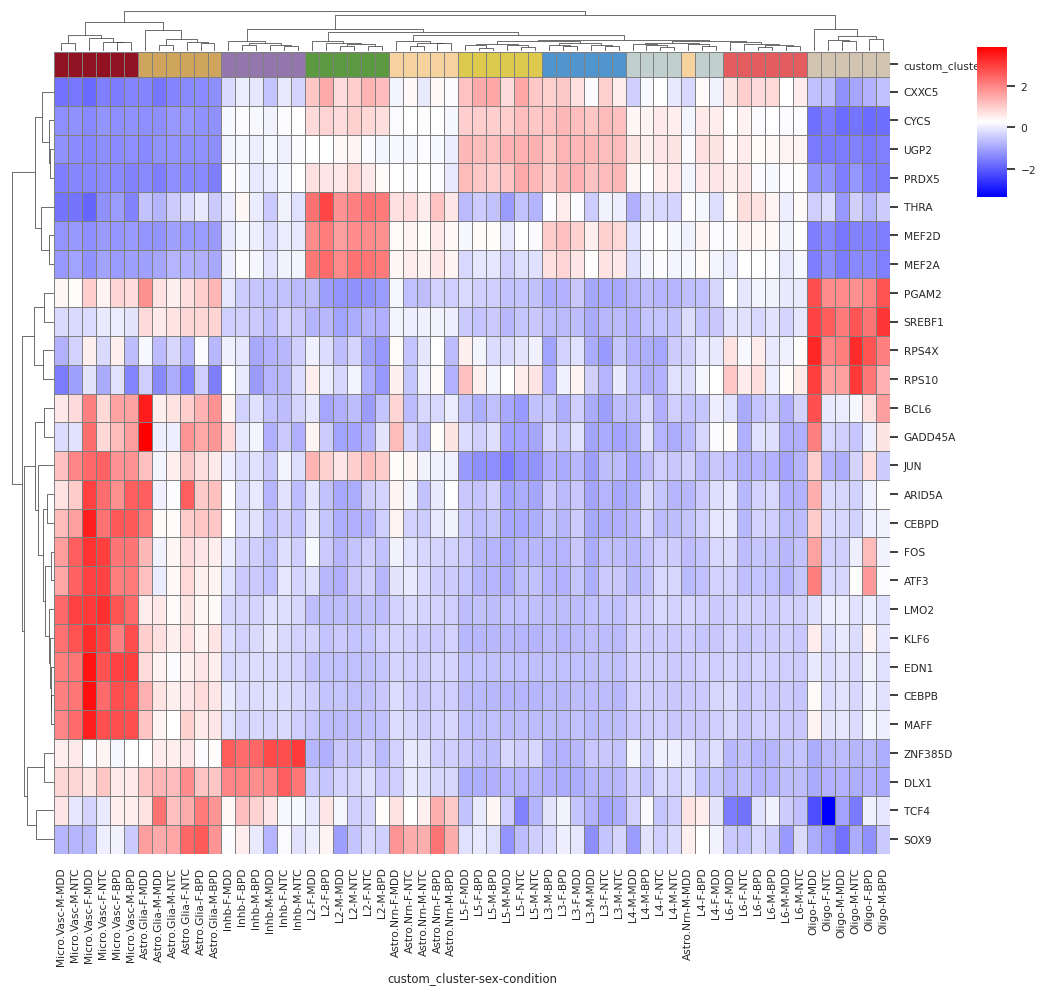

In [32]:
sns.clustermap(df_means[tfDEGs].T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15), linewidths=0.5, linecolor='grey')

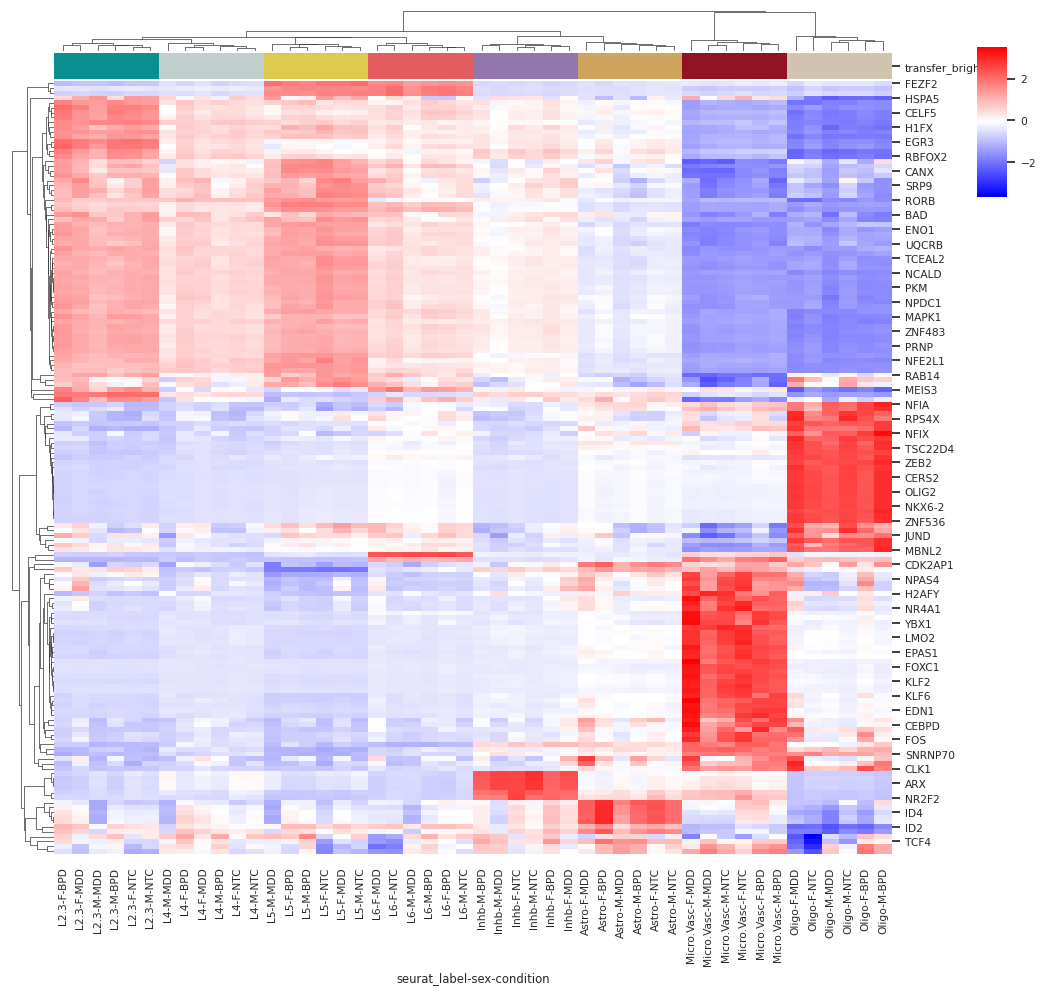

In [33]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['seurat_label','sex','condition']]
df_means = df_scores.groupby(by=['seurat_label','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['transfer_bright'] = [x[0] for x in df_means.index]
row_colors = colors_df['transfer_bright'].map(transfer_bright)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

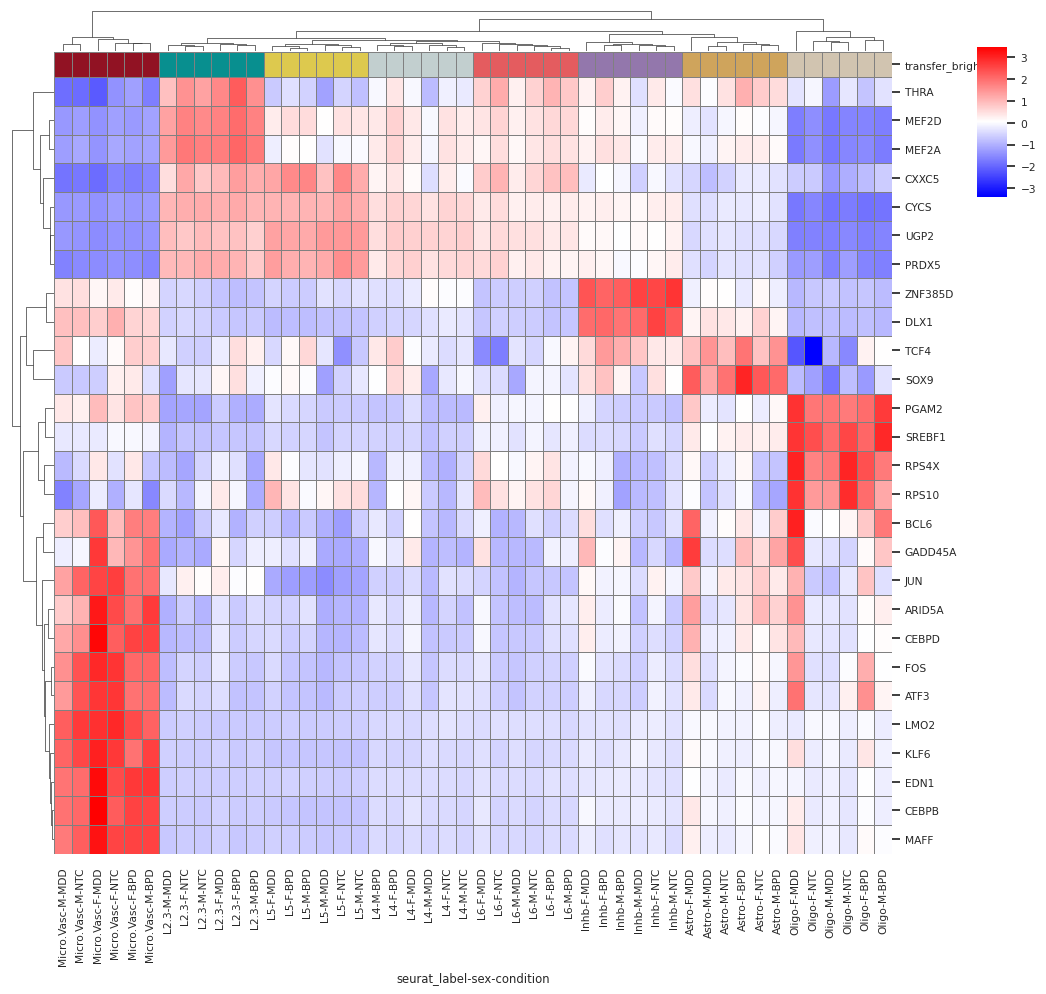

In [34]:
sns.clustermap(df_means[tfDEGs].T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15), linewidths=0.5, linecolor='grey')

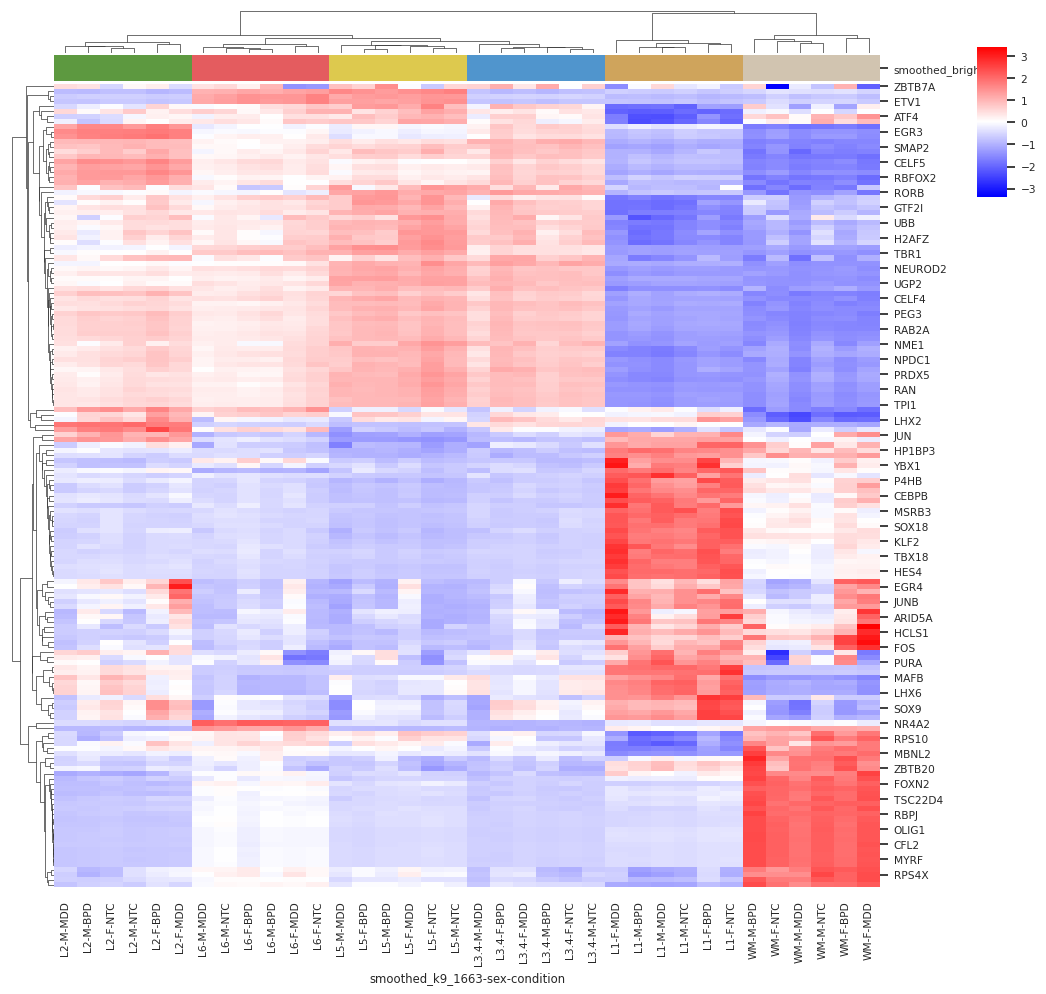

In [30]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['smoothed_k9_1663','sex','condition']]
df_scores = df_scores.loc[-df_scores['smoothed_k9_1663'].isin(['Vasc','GABA'])]
df_means = df_scores.groupby(by=['smoothed_k9_1663','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['smoothed_bright'] = [x[0] for x in df_means.index]
row_colors = colors_df['smoothed_bright'].map(smoothed_bright)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

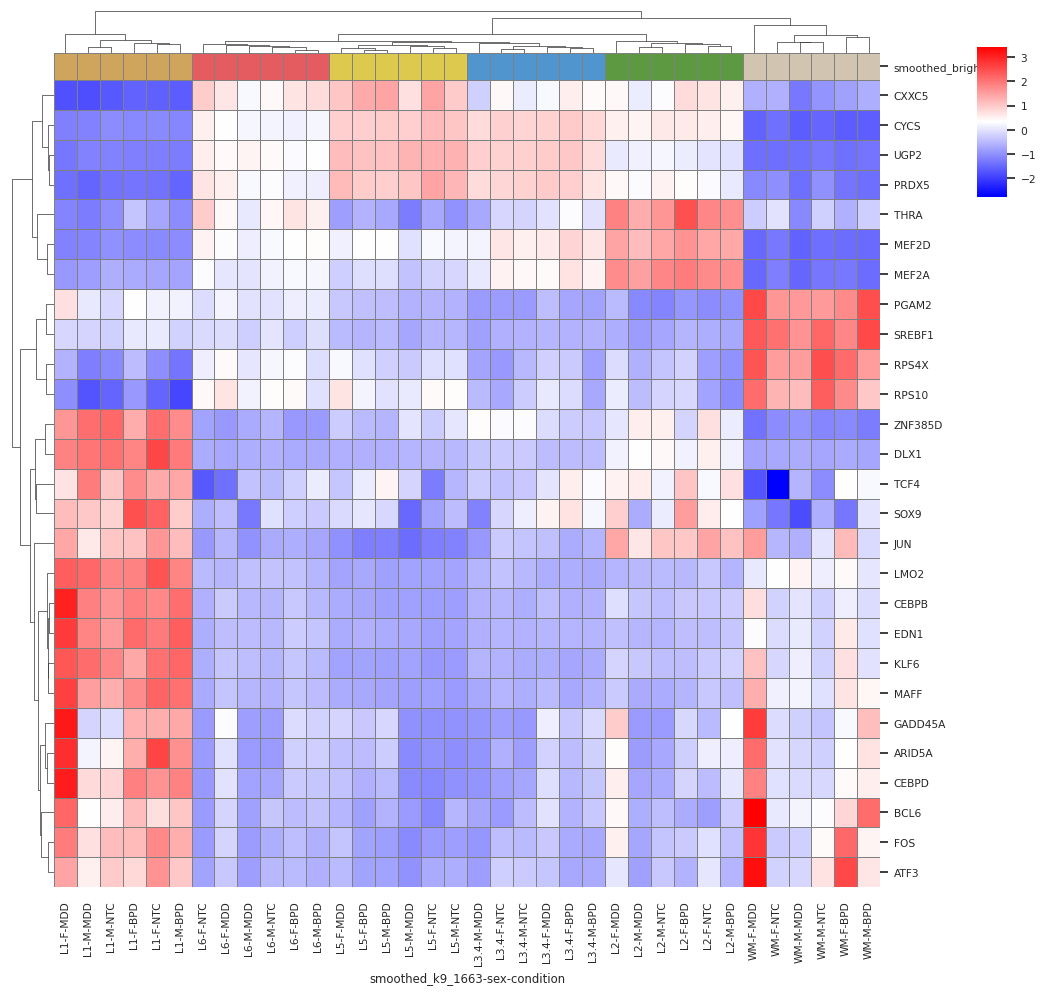

In [28]:
sns.clustermap(df_means[tfDEGs].T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15), linewidths=0.5, linecolor='grey')